In [26]:
import pypsa
import pandas as pd
import numpy as np
from pathlib import Path

RESULTS = Path("/Users/fowfloi/Documents/pypsa-earth/results")

def load_net(name):
    d = RESULTS / name / "networks"
    files = list(d.glob("*.nc"))
    return pypsa.Network(files[0]) if files else None

def full_summary(n, label):
    """Dump everything relevant about one network."""
    # Connected buses only
    n.determine_network_topology()
    main = n.buses.sub_network.mode()[0]
    connected = n.buses.index[n.buses.sub_network == main]
    gens = n.generators[n.generators.bus.isin(connected)]
    sto = n.storage_units[n.storage_units.bus.isin(connected)]

    # Capacity by carrier
    cap = gens.groupby("carrier").p_nom_opt.sum() / 1e3
    sc = sto.groupby("carrier").p_nom_opt.sum() / 1e3

    # Generation by carrier (TWh) from generators
    gen_twh = {}
    for c in gens.carrier.unique():
        idx = gens[gens.carrier == c].index
        gen_twh[c] = n.generators_t.p[idx].sum().sum() / 1e6

    # Hydro generation from storage units
    hyd_idx = sto[sto.carrier == "hydro"].index
    hydro_twh = n.storage_units_t.p[hyd_idx].clip(lower=0).sum().sum() / 1e6 if len(hyd_idx) else 0.0

    # Load shedding (as generator)
    shed_idx = gens[gens.carrier == "load shedding"].index
    shed_twh = n.generators_t.p[shed_idx].sum().sum() / 1e6 if len(shed_idx) else 0.0

    # Demand
    load_cols = [c for c in n.loads_t.p_set.columns if c in connected]
    demand_twh = n.loads_t.p_set[load_cols].sum().sum() / 1e6

    # Gas split
    ccgt_cap = cap.get("CCGT", 0.0)
    ocgt_cap = cap.get("OCGT", 0.0)
    ccgt_gen = gen_twh.get("CCGT", 0.0)
    ocgt_gen = gen_twh.get("OCGT", 0.0)

    # CCGT and OCGT capacity factors (actual dispatch / theoretical max)
    ccgt_idx = gens[gens.carrier == "CCGT"].index
    ocgt_idx = gens[gens.carrier == "OCGT"].index
    ccgt_cf = (n.generators_t.p[ccgt_idx].sum().sum() / (gens.loc[ccgt_idx, "p_nom_opt"].sum() * 8784)) if len(ccgt_idx) and gens.loc[ccgt_idx, "p_nom_opt"].sum() > 0 else 0
    ocgt_cf = (n.generators_t.p[ocgt_idx].sum().sum() / (gens.loc[ocgt_idx, "p_nom_opt"].sum() * 8784)) if len(ocgt_idx) and gens.loc[ocgt_idx, "p_nom_opt"].sum() > 0 else 0

    # Fuel cost embedded in MC
    mc = gens[["carrier", "marginal_cost"]].drop_duplicates("carrier").set_index("carrier")["marginal_cost"].to_dict()

    # Emissions using network's own carrier CO2 intensity
    co2_map = n.carriers["co2_emissions"].reindex(gens.carrier.unique()).fillna(0.0)
    fuel_mwh = n.generators_t.p[gens.index].div(gens.efficiency.replace(0, np.nan), axis=1)
    emissions_t = fuel_mwh.mul(gens.carrier.map(co2_map), axis=1).sum().sum()

    # Transmission expansion
    new_lines_gwkm = ((n.lines.s_nom_opt - n.lines.s_nom).clip(lower=0) * n.lines.length).sum() / 1e3

    # Total cost
    total_cost_eur = n.objective
    EUR_TO_USD = 1 / 0.7532

    return {
        "label": label,
        "demand_TWh": round(demand_twh, 2),
        "shed_TWh": round(shed_twh, 3),
        "shed_pct": round(100 * shed_twh / demand_twh, 2) if demand_twh else 0,
        "solar_GW": round(cap.get("solar", 0), 2),
        "wind_GW": round(cap.get("onwind", 0), 2),
        "battery_GW": round(sc.get("battery", 0), 2),
        "hydro_GW": round(sc.get("hydro", 0), 2),
        "CCGT_GW": round(ccgt_cap, 2),
        "OCGT_GW": round(ocgt_cap, 2),
        "gas_GW_total": round(ccgt_cap + ocgt_cap, 2),
        "solar_TWh": round(gen_twh.get("solar", 0), 2),
        "wind_TWh": round(gen_twh.get("onwind", 0), 2),
        "hydro_TWh": round(hydro_twh, 2),
        "CCGT_TWh": round(ccgt_gen, 2),
        "OCGT_TWh": round(ocgt_gen, 2),
        "gas_TWh_total": round(ccgt_gen + ocgt_gen, 2),
        "CCGT_CF": round(ccgt_cf, 3),
        "OCGT_CF": round(ocgt_cf, 3),
        "MC_CCGT": round(mc.get("CCGT", 0), 2),
        "MC_OCGT": round(mc.get("OCGT", 0), 2),
        "emissions_Mt": round(emissions_t / 1e6, 2),
        "new_tx_GWkm": round(new_lines_gwkm, 1),
        "cost_BnUSD": round(total_cost_eur * EUR_TO_USD / 1e9, 3),
    }

# Build the comparison table
runs = [
    # Baselines
    ("cap_exp_2030_uniform_WACC",                  "B1 uniform 10% uncon"),
    ("cap_exp_2030_uniform_WACC_NDC",              "B2 uniform 10% NDC"),
    ("cap_exp_2030_split_wacc",                    "B3 Hatton uncon"),
    ("cap_exp_2030_split_wacc_NDC",                "B4 Hatton NDC"),
    # Primary sweep — unconstrained
    ("nigeria_2030_wacc_0700",                     "sweep 7% uncon"),
    ("nigeria_2030_wacc_1100",                     "sweep 11% uncon"),
    ("nigeria_2030_wacc_1379",                     "sweep 13.79% uncon"),
    ("nigeria_2030_wacc_2700",                     "sweep 27% uncon"),
    # Primary sweep — NDC
    ("nigeria_2030_wacc_0700_ndc",                 "sweep 7% NDC"),
    ("nigeria_2030_wacc_1100_ndc",                 "sweep 11% NDC"),
    ("nigeria_2030_wacc_1379_ndc",                 "sweep 13.79% NDC"),
    ("nigeria_2030_wacc_2700_ndc",                 "sweep 27% NDC"),
    # Battery sensitivity
    ("nigeria_2030_wacc_0900_battery_hatton",      "battery 14.68% @ solar 9%"),
    ("nigeria_2030_wacc_1100_battery_hatton",      "battery 14.68% @ solar 11%"),
    # Gas price sensitivity
    ("nigeria_2030_wacc_1379_gas_218",             "gas $2.18 @ renew 13.79%"),
    ("nigeria_2030_wacc_1379_gas_400",             "gas $4.00 @ renew 13.79%"),
    ("nigeria_2030_wacc_1379_gas_600",             "gas $6.00 @ renew 13.79%"),
    # New runs
    ("nigeria_2030_wacc_1379_gas_218_uncon",       "gas $2.18 uncon @ 13.79%"),
    ("nigeria_2030_wacc_1379_gas_400_uncon",       "gas $4.00 uncon @ 13.79%"),
    ("nigeria_2030_wacc_1379_gas_600_uncon",       "gas $6.00 uncon @ 13.79%"),
    ("nigeria_2030_wacc_1379_battery_hatton_ndc",  "battery 14.68% NDC @ 13.79%"),
    # Combined
    ("nigeria_2030_wacc_0700_gas_450_ndc",         "combined: renew 7% + gas $4.50"),
]

rows = []
for name, label in runs:
    n = load_net(name)
    if n is None:
        print(f"MISSING: {name}")
        continue
    rows.append(full_summary(n, label))

df = pd.DataFrame(rows)
df.to_csv("analysis/diagnostic_full.csv", index=False)

# Print column-wise so you can read it
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
print(df.to_string(index=False))

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraint

                         label  demand_TWh  shed_TWh  shed_pct  solar_GW  wind_GW  battery_GW  hydro_GW  CCGT_GW  OCGT_GW  gas_GW_total  solar_TWh  wind_TWh  hydro_TWh  CCGT_TWh  OCGT_TWh  gas_TWh_total  CCGT_CF  OCGT_CF  MC_CCGT  MC_OCGT  emissions_Mt  new_tx_GWkm  cost_BnUSD
          B1 uniform 10% uncon       72.02       0.0       0.0      2.68      0.0        0.00      2.68     3.44    28.66         32.10       4.65       0.0       8.45      5.30     53.61          58.91    0.175    0.213     4.96     4.36         27.70        146.3       3.539
            B2 uniform 10% NDC       71.88       0.0       0.0     25.90      0.0        9.35      2.68     3.44     9.21         12.66      44.19       0.0       8.42      8.63     12.18          20.80    0.285    0.150     4.96     4.36          8.82          0.0       5.011
               B3 Hatton uncon       72.02       0.0       0.0      2.71      0.0        0.04      2.68     3.44    28.61         32.06       4.70       0.0       8.2

In [25]:
n = pypsa.Network("results/nigeria_2030_wacc_1379_ndc/networks/elec_s_10_ec_lcopt_1h.nc")
solar = n.generators[n.generators.carrier == "solar"]
print((solar.p_nom_opt / solar.p_nom_max).describe())
print("at ceiling:", (solar.p_nom_opt >= solar.p_nom_max * 0.999).sum(), "of", len(solar))

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


count    1.000000e+01
mean     2.002101e-02
std      3.684652e-02
min      1.376128e-08
25%      9.540669e-08
50%      5.471630e-03
75%      1.764887e-02
max      1.189178e-01
dtype: float64
at ceiling: 0 of 10


In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3,
})

RESULTS = Path("/Users/fowfloi/Documents/pypsa-earth/results")
OUT = Path("/Users/fowfloi/Documents/pypsa-earth/analysis")
OUT.mkdir(exist_ok=True)

EUR_TO_USD = 1.0 / 0.7532
print(f"EUR_TO_USD = {EUR_TO_USD:.4f}")

# The 12 WACC sweep points
WACC_POINTS = [0.07, 0.09, 0.11, 0.12, 0.13, 0.1379,
               0.1468, 0.16, 0.18, 0.20, 0.23, 0.27]

# Four baselines with correct directory names
BASELINES = {
    "B1_uniform_uncon": "cap_exp_2030_uniform_WACC",
    "B2_uniform_ndc":   "cap_exp_2030_uniform_WACC_NDC",
    "B3_split_uncon":   "cap_exp_2030_split_wacc",
    "B4_split_ndc":     "cap_exp_2030_split_wacc_NDC",
}

# Supplementary runs
BATTERY_RUNS = {
    "battery_hatton_9pct":  "nigeria_2030_wacc_0900_battery_hatton",
    "battery_hatton_11pct": "nigeria_2030_wacc_1100_battery_hatton",
}
GAS_RUNS = {
    "gas_218": "nigeria_2030_wacc_1379_gas_218",
    "gas_400": "nigeria_2030_wacc_1379_gas_400",
    "gas_600": "nigeria_2030_wacc_1379_gas_600",
}

EUR_TO_USD = 1.3277


In [2]:
def load_network(run_name):
    d = RESULTS / run_name / "networks"
    files = list(d.glob("*.nc"))
    return pypsa.Network(files[0]) if files else None

def get_connected(n):
    n.determine_network_topology()
    main_sub = n.buses.sub_network.mode()[0]
    return n.buses.index[n.buses.sub_network == main_sub].tolist()

In [3]:
def summarise(n, wacc, constraint, label, sweep_tag=None):
    EUR_TO_USD_local = 1.0 / 0.7532

    connected = get_connected(n)
    gens = n.generators[n.generators.bus.isin(connected)]
    sto = n.storage_units[n.storage_units.bus.isin(connected)]

    row = {"run": label, "wacc": wacc, "constraint": constraint}

    # Capacity (GW)
    cap = gens.groupby("carrier").p_nom_opt.sum() / 1e3
    for c in ["solar", "onwind", "CCGT", "OCGT", "oil", "biomass"]:
        row[f"cap_{c}_gw"] = float(cap.get(c, 0.0))
    bat = sto[sto.carrier == "battery"]
    hyd = sto[sto.carrier == "hydro"]
    row["cap_battery_gw"] = float(bat.p_nom_opt.sum() / 1e3) if len(bat) else 0.0
    row["cap_hydro_gw"]   = float(hyd.p_nom.sum()    / 1e3) if len(hyd) else 0.0

    # Generation (TWh)
    gen = {}
    for c in gens.carrier.unique():
        cols = gens[gens.carrier == c].index
        if len(cols):
            gen[c] = float(n.generators_t.p[cols].sum().sum() / 1e6)
    if len(hyd):
        gen["hydro"] = float(n.storage_units_t.p[hyd.index].clip(lower=0).sum().sum() / 1e6)
    else:
        gen["hydro"] = 0.0
    for c in ["solar", "onwind", "CCGT", "OCGT", "hydro", "oil", "biomass"]:
        row[f"gen_{c}_twh"] = gen.get(c, 0.0)

    # Shedding
    shed_gens = gens[gens.carrier == "load shedding"]
    shed_twh = float(n.generators_t.p[shed_gens.index].sum().sum() / 1e6) if len(shed_gens) else 0.0
    load_cols = [c for c in n.loads_t.p_set.columns if c in connected]
    demand_twh = n.loads_t.p_set[load_cols].sum().sum() / 1e6
    row["demand_twh"] = demand_twh
    row["served_twh"] = demand_twh - shed_twh
    row["shed_twh"]   = shed_twh
    row["shed_pct"]   = 100 * shed_twh / demand_twh if demand_twh else 0.0

    # Total generation excludes shedding
    row["gen_total_twh"] = sum(v for k, v in gen.items() if k != "load shedding")

    # Shares
    tot = row["gen_total_twh"]
    if tot > 0:
        row["share_solar_pct"] = 100 * row["gen_solar_twh"] / tot
        row["share_wind_pct"]  = 100 * row["gen_onwind_twh"] / tot
        row["share_renew_pct"] = 100 * (row["gen_solar_twh"] + row["gen_onwind_twh"] + row["gen_hydro_twh"]) / tot
        row["share_gas_pct"]   = 100 * (row["gen_CCGT_twh"] + row["gen_OCGT_twh"]) / tot
    else:
        for k in ["share_solar_pct","share_wind_pct","share_renew_pct","share_gas_pct"]:
            row[k] = 0.0

    # Emissions
    co2_map = n.carriers["co2_emissions"].reindex(gens.carrier.unique()).fillna(0.0)
    eff = gens.efficiency.replace(0, np.nan)
    fuel_mwh = n.generators_t.p[gens.index].div(eff, axis=1)
    emissions_t = fuel_mwh.mul(gens.carrier.map(co2_map), axis=1).sum().sum()
    row["emissions_mt_co2"] = emissions_t / 1e6

    # Cost decomposition
    gen_capex = ((gens.p_nom_opt - gens.p_nom).clip(lower=0) * gens.capital_cost).sum()
    gen_opex  = (n.generators_t.p[gens.index] * gens.marginal_cost).sum().sum()
    lines_new = (n.lines.s_nom_opt - n.lines.s_nom).clip(lower=0)
    line_capex = (lines_new * n.lines.capital_cost).sum()
    storage_capex = (sto.capital_cost * sto.p_nom_opt).sum()
    total_cost = gen_capex + gen_opex + line_capex

    row["cost_gen_capex_bn_usd"]     = gen_capex * EUR_TO_USD_local / 1e9
    row["cost_gen_opex_bn_usd"]      = gen_opex * EUR_TO_USD_local / 1e9
    row["cost_line_capex_bn_usd"]    = line_capex * EUR_TO_USD_local / 1e9
    row["cost_storage_capex_bn_usd"] = storage_capex * EUR_TO_USD_local / 1e9
    row["total_cost_bn_usd"]         = total_cost * EUR_TO_USD_local / 1e9
    row["cost_per_mwh_usd"]          = (total_cost * EUR_TO_USD_local) / (row["served_twh"] * 1e6) if row["served_twh"] else np.nan

    # Transmission
    if "s_nom_opt" in n.lines.columns:
        row["line_capacity_gwkm"] = float((n.lines.s_nom_opt * n.lines.length).sum() / 1e3)
    else:
        row["line_capacity_gwkm"] = 0.0

    return row

In [4]:
rows = []

# 24 primary sweep points
for wacc in WACC_POINTS:
    tag = f"{int(round(wacc * 10000)):04d}"
    for suffix, constraint in [("", "unconstrained"), ("_ndc", "ndc")]:
        run_name = f"nigeria_2030_wacc_{tag}{suffix}"
        n = load_network(run_name)
        if n is None:
            print(f"MISSING: {run_name}")
            continue
        rows.append(summarise(n, wacc, constraint, run_name, sweep_tag=tag))
        print(f"Loaded {run_name}")

# 4 baselines
for label, run_name in BASELINES.items():
    n = load_network(run_name)
    if n is None:
        print(f"MISSING baseline: {label} ({run_name})")
        continue
    rows.append(summarise(n, np.nan, label, run_name))
    print(f"Loaded {label}")

# 2 battery sensitivity runs
for label, run_name in BATTERY_RUNS.items():
    n = load_network(run_name)
    if n is None:
        print(f"MISSING battery: {label} ({run_name})")
        continue
    wacc_guess = 0.09 if "9pct" in label else 0.11
    rows.append(summarise(n, wacc_guess, "battery_sensitivity", label))
    print(f"Loaded {label}")

# 3 gas sensitivity runs
for label, run_name in GAS_RUNS.items():
    n = load_network(run_name)
    if n is None:
        print(f"MISSING gas: {label} ({run_name})")
        continue
    rows.append(summarise(n, 0.1379, "gas_sensitivity", label))
    print(f"Loaded {label}")

df = pd.DataFrame(rows)
df.to_csv(OUT / "master_diagnostics.csv", index=False)
print(f"\nTotal rows: {len(df)}")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


Loaded nigeria_2030_wacc_0700
Loaded nigeria_2030_wacc_0700_ndc


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


Loaded nigeria_2030_wacc_0900


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


...

Loaded battery_hatton_9pct
Loaded battery_hatton_11pct


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


Loaded gas_218
Loaded gas_400


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


Loaded gas_600

Total rows: 33


In [5]:
sweep = df[df.constraint.isin(["unconstrained", "ndc"])].copy()
sweep = sweep.sort_values(["constraint", "wacc"]).reset_index(drop=True)

headline = sweep[[
    "wacc", "constraint",
    "cap_solar_gw", "cap_CCGT_gw", "cap_OCGT_gw", "cap_battery_gw",
    "gen_solar_twh", "gen_hydro_twh", "gen_CCGT_twh", "gen_OCGT_twh",
    "share_renew_pct", "share_gas_pct",
    "shed_pct", "emissions_mt_co2",
    "cost_per_mwh_usd",
]].copy()
headline["wacc"] = (headline.wacc * 100).round(2)
headline.round(2).to_csv(OUT / "rq1_headline.csv", index=False)
headline.round(2)

,wacc,constraint,cap_solar_gw,cap_CCGT_gw,cap_OCGT_gw,cap_battery_gw,gen_solar_twh,gen_hydro_twh,gen_CCGT_twh,gen_OCGT_twh,share_renew_pct,share_gas_pct,shed_pct,emissions_mt_co2,cost_per_mwh_usd
0,7.00,ndc,25.98,3.44,8.74,9.70,44.39,8.22,8.77,12.07,71.63,28.37,0.0,8.82,21.77
1,9.00,ndc,25.98,3.44,8.74,9.70,44.40,8.22,8.77,12.08,71.63,28.37,0.0,8.82,25.45
2,11.00,ndc,25.98,3.44,8.74,9.70,44.40,8.22,8.77,12.08,71.63,28.37,0.0,8.82,29.30
3,12.00,ndc,25.98,3.44,8.74,9.70,44.40,8.22,8.77,12.08,71.63,28.37,0.0,8.82,31.27
4,13.00,ndc,25.98,3.44,8.74,9.70,44.40,8.22,8.77,12.08,71.63,28.37,0.0,8.82,33.25
5,13.79,ndc,25.98,3.44,8.74,9.70,44.40,8.22,8.77,12.08,71.63,28.37,0.0,8.82,34.85
6,14.68,ndc,25.98,3.44,8.74,9.70,44.40,8.22,8.77,12.08,71.63,28.37,0.0,8.82,36.67
7,16.00,ndc,25.98,3.44,8.74,9.70,44.40,8.22,8.77,12.08,71.63,28.37,0.0,8.82,39.30
8,18.00,ndc,25.98,3.44,8.74,9.70,44.40,8.22,8.77,12.08,71.63,28.37,0.0,8.82,43.36
9,20.00,ndc,25.98,3.44,8.74,9.70,44.40,8.22,8.77,12.08,71.63,28.37,0.0,8.82,47.45


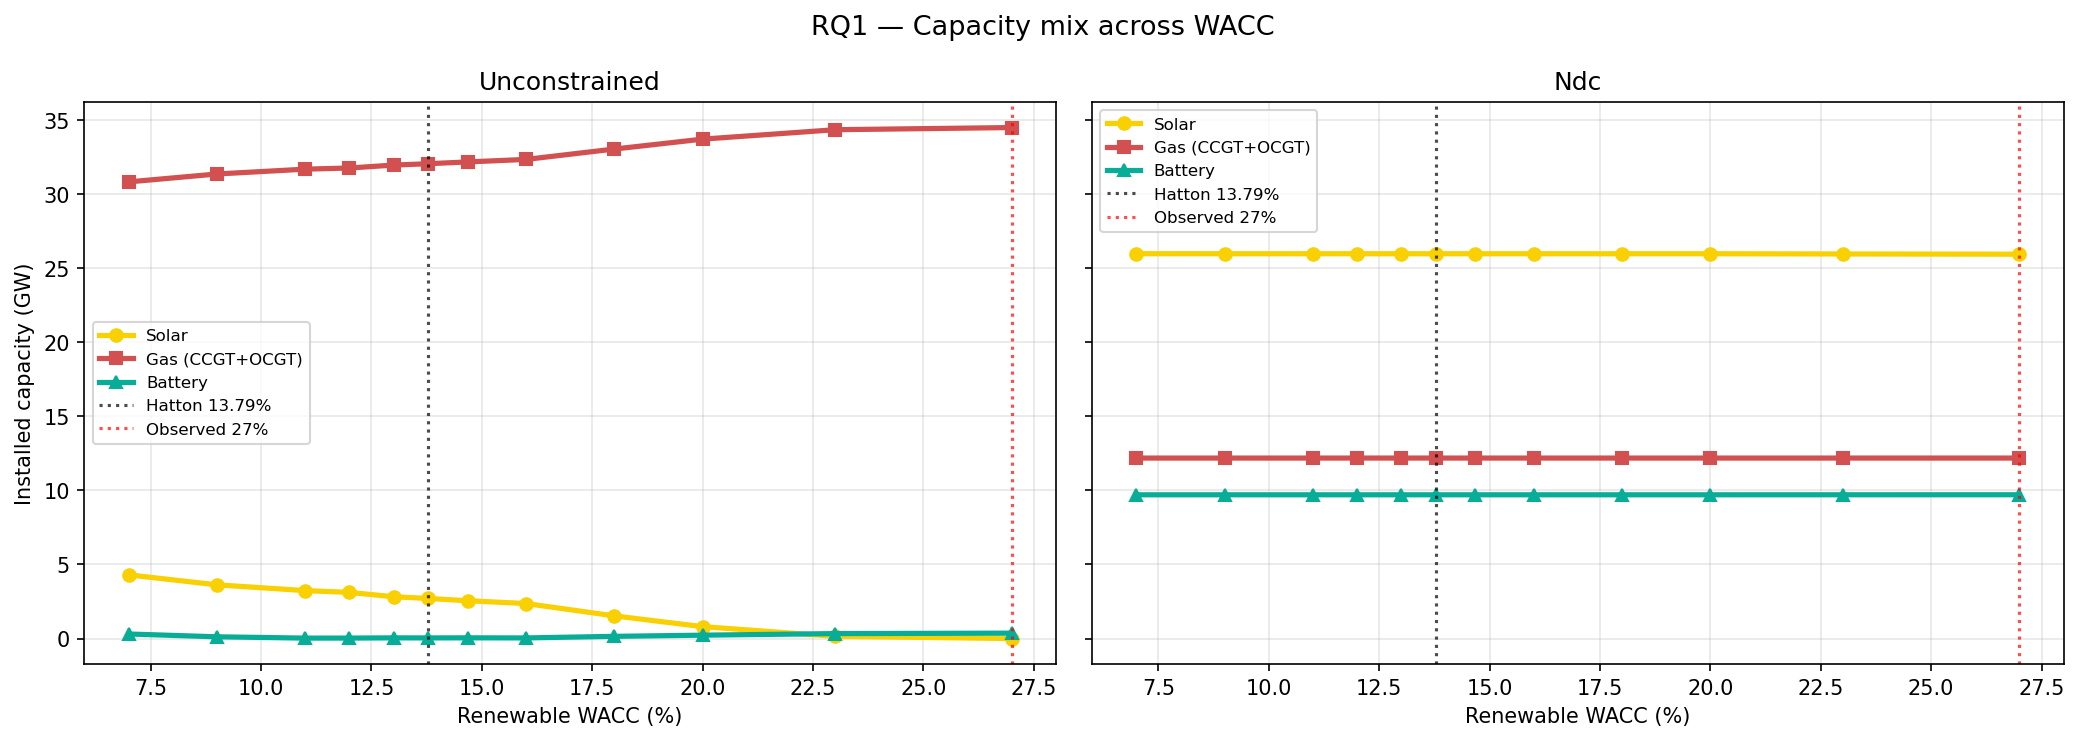

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, constraint in zip(axes, ["unconstrained", "ndc"]):
    sub = sweep[sweep.constraint == constraint].sort_values("wacc")
    x = sub.wacc * 100

    ax.plot(x, sub.cap_solar_gw, "o-", color="#f9d002", lw=2.5, label="Solar")
    ax.plot(x, sub.cap_CCGT_gw + sub.cap_OCGT_gw, "s-", color="#d35050", lw=2.5, label="Gas (CCGT+OCGT)")
    ax.plot(x, sub.cap_battery_gw, "^-", color="#08ad97", lw=2.5, label="Battery")

    ax.axvline(13.79, color="black", linestyle=":", alpha=0.7, label="Hatton 13.79%")
    ax.axvline(27, color="red", linestyle=":", alpha=0.7, label="Observed 27%")
    ax.set_xlabel("Renewable WACC (%)")
    ax.set_title(constraint.capitalize())
    ax.legend(fontsize=8)

axes[0].set_ylabel("Installed capacity (GW)")
fig.suptitle("RQ1 — Capacity mix across WACC", fontsize=13)
plt.tight_layout()
plt.savefig(OUT / "fig_rq1_capacity_crossover.png", bbox_inches="tight")
plt.show()

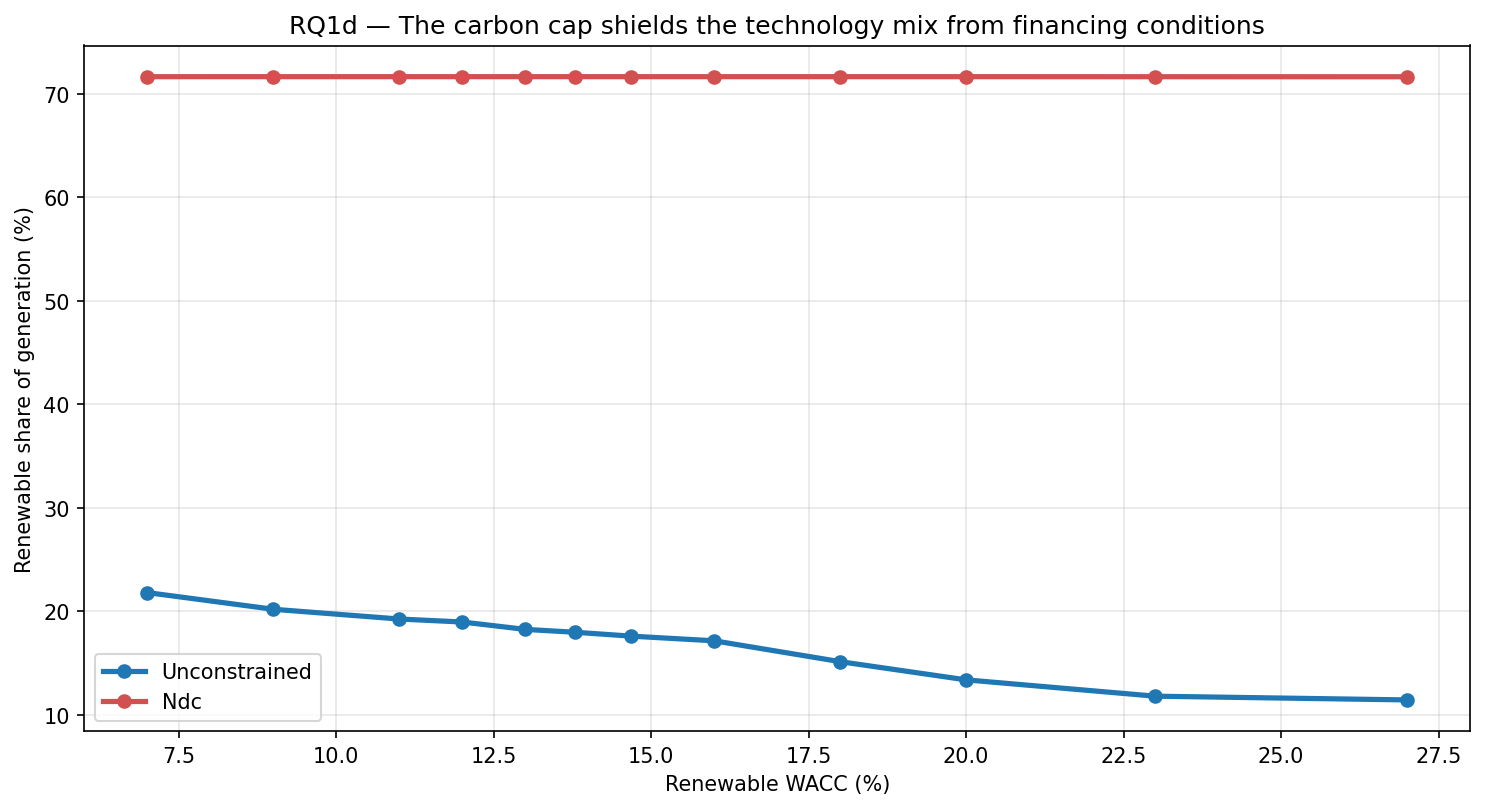

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for constraint, color in [("unconstrained", "#1f77b4"), ("ndc", "#d35050")]:
    sub = sweep[sweep.constraint == constraint].sort_values("wacc")
    ax.plot(sub.wacc * 100, sub.share_renew_pct, "o-", color=color, lw=2.5, label=constraint.capitalize())

ax.set_xlabel("Renewable WACC (%)")
ax.set_ylabel("Renewable share of generation (%)")
ax.set_title("RQ1d — The carbon cap shields the technology mix from financing conditions")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "fig_rq1d_carbon_shield.png", bbox_inches="tight")
plt.show()

In [8]:
def find_wacc_threshold(sub, condition):
    sub = sub.sort_values("wacc")
    hit = sub[condition]
    return float(hit.wacc.iloc[0] * 100) if len(hit) else None

results = []
for constraint in ["unconstrained", "ndc"]:
    sub = sweep[sweep.constraint == constraint].reset_index(drop=True)
    results.append({
        "constraint": constraint,
        "solar > gas (GW)":     find_wacc_threshold(sub, sub.cap_solar_gw >= sub.cap_CCGT_gw + sub.cap_OCGT_gw),
        "solar > gas (TWh)":    find_wacc_threshold(sub, sub.gen_solar_twh >= sub.gen_CCGT_twh + sub.gen_OCGT_twh),
        "renew > 30%":          find_wacc_threshold(sub, sub.share_renew_pct >= 30),
        "renew > 50%":          find_wacc_threshold(sub, sub.share_renew_pct >= 50),
        "renew > 70%":          find_wacc_threshold(sub, sub.share_renew_pct >= 70),
        "emissions < 10 Mt":    find_wacc_threshold(sub, sub.emissions_mt_co2 <= 10),
    })

inflection = pd.DataFrame(results)
inflection.to_csv(OUT / "rq1_inflection.csv", index=False)
inflection.round(2)

,constraint,solar > gas (GW),solar > gas (TWh),renew > 30%,renew > 50%,renew > 70%,emissions < 10 Mt
0,unconstrained,NaN,NaN,NaN,NaN,NaN,NaN
1,ndc,7.0,7.0,7.0,7.0,7.0,7.0


In [9]:
# Merge constrained and unconstrained for the same WACC
pivot = sweep.pivot_table(index="wacc", columns="constraint", values=["total_cost_bn_usd", "emissions_mt_co2", "share_renew_pct"])
pivot.columns = ["_".join(c) for c in pivot.columns]
pivot = pivot.reset_index()

pivot["cost_premium_bn_usd"] = pivot["total_cost_bn_usd_ndc"] - pivot["total_cost_bn_usd_unconstrained"]
pivot["emissions_reduction_mt"] = pivot["emissions_mt_co2_unconstrained"] - pivot["emissions_mt_co2_ndc"]

pivot["carbon_premium_usd_per_tco2"] = (
    pivot["cost_premium_bn_usd"] * 1e9 / (pivot["emissions_reduction_mt"] * 1e6)
).replace([np.inf, -np.inf], np.nan)

pivot["wacc_pct"] = (pivot.wacc * 100).round(2)
pivot.to_csv(OUT / "rq2_decarbonisation.csv", index=False)
pivot.round(3)

,wacc,emissions_mt_co2_ndc,emissions_mt_co2_unconstrained,share_renew_pct_ndc,share_renew_pct_unconstrained,total_cost_bn_usd_ndc,total_cost_bn_usd_unconstrained,cost_premium_bn_usd,emissions_reduction_mt,carbon_premium_usd_per_tco2,wacc_pct
0,0.070,8.824,26.476,71.626,21.818,1.565,2.502,-0.938,17.651,-53.127,7.00
1,0.090,8.824,27.013,71.628,20.207,1.829,2.568,-0.739,18.189,-40.611,9.00
2,0.110,8.824,27.333,71.628,19.267,2.106,2.616,-0.510,18.509,-27.573,11.00
3,0.120,8.824,27.429,71.628,18.979,2.247,2.633,-0.386,18.605,-20.743,12.00
4,0.130,8.824,27.666,71.628,18.266,2.390,2.648,-0.257,18.842,-13.658,13.00
5,0.138,8.824,27.760,71.628,17.990,2.505,2.660,-0.155,18.936,-8.182,13.79
6,0.147,8.824,27.886,71.628,17.615,2.635,2.672,-0.037,19.062,-1.940,14.68
7,0.160,8.824,28.041,71.628,17.164,2.824,2.691,0.133,19.217,6.927,16.00
8,0.180,8.824,28.725,71.628,15.151,3.117,2.701,0.416,19.901,20.917,18.00
9,0.200,8.824,29.334,71.628,13.393,3.410,2.701,0.709,20.510,34.583,20.00


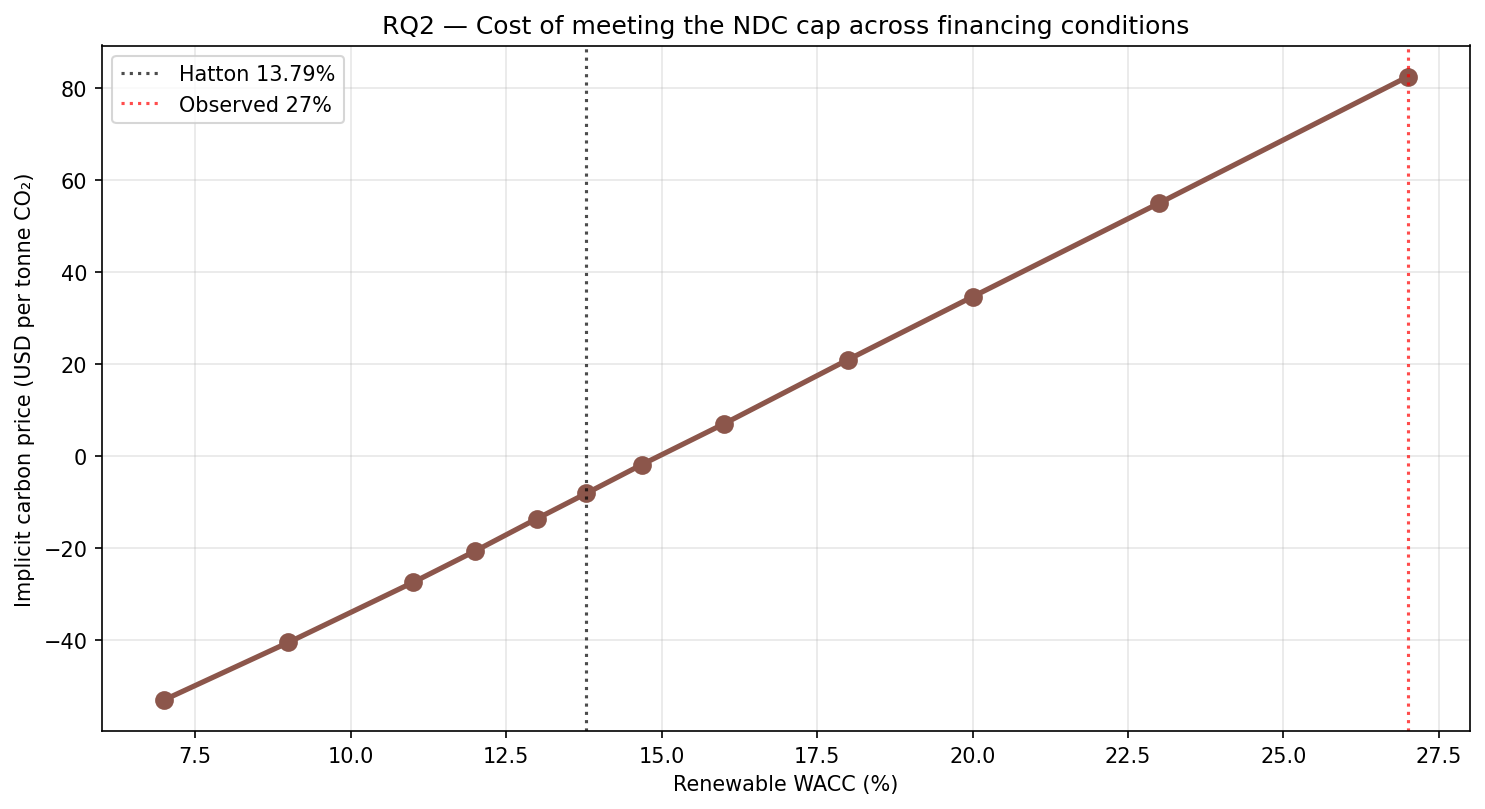

In [10]:
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(pivot.wacc_pct, pivot.carbon_premium_usd_per_tco2, "o-",
        color="#8c564b", lw=2.5, markersize=8)

ax.set_xlabel("Renewable WACC (%)")
ax.set_ylabel("Implicit carbon price (USD per tonne CO₂)")
ax.set_title("RQ2 — Cost of meeting the NDC cap across financing conditions")
ax.grid(alpha=0.3)
ax.axvline(13.79, color="black", linestyle=":", alpha=0.7, label="Hatton 13.79%")
ax.axvline(27, color="red", linestyle=":", alpha=0.7, label="Observed 27%")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_rq2_implicit_carbon_price.png", bbox_inches="tight")
plt.show()

In [11]:
baselines = df[df.constraint.isin(list(BASELINES.keys()))][[
    "constraint",
    "cap_solar_gw", "cap_CCGT_gw", "cap_OCGT_gw", "cap_battery_gw",
    "gen_solar_twh", "gen_hydro_twh", "gen_CCGT_twh", "gen_OCGT_twh",
    "share_renew_pct", "share_gas_pct",
    "shed_pct", "emissions_mt_co2", "cost_per_mwh_usd",
]].copy()
baselines.round(2).to_csv(OUT / "rq3_baselines.csv", index=False)
baselines.round(2)

,constraint,cap_solar_gw,cap_CCGT_gw,cap_OCGT_gw,cap_battery_gw,gen_solar_twh,gen_hydro_twh,gen_CCGT_twh,gen_OCGT_twh,share_renew_pct,share_gas_pct,shed_pct,emissions_mt_co2,cost_per_mwh_usd
24,B1_uniform_uncon,2.68,3.44,28.66,0.00,4.65,8.45,5.30,53.61,18.20,81.80,0.0,27.70,37.00
25,B2_uniform_ndc,25.90,3.44,9.21,9.35,44.19,8.42,8.63,12.18,71.67,28.33,0.0,8.82,35.42
26,B3_split_uncon,2.71,3.44,28.61,0.04,4.70,8.26,5.40,53.67,17.99,82.01,0.0,27.76,36.94
27,B4_split_ndc,25.98,3.44,8.74,9.70,44.40,8.22,8.77,12.08,71.63,28.37,0.0,8.82,34.85


In [21]:
# Compare the two battery runs to their primary counterparts
battery = df[df.constraint == "battery_sensitivity"][[
    "constraint", "wacc", "cap_solar_gw", "cap_battery_gw",
    "cap_CCGT_gw", "cap_OCGT_gw", "share_renew_pct", "cost_per_mwh_usd"
]].copy()

# Reference from primary sweep at 9% and 11% unconstrained
primary_9 = sweep[(sweep.constraint == "unconstrained") & (sweep.wacc == 0.09)][[
    "constraint", "wacc", "cap_solar_gw", "cap_battery_gw",
    "cap_CCGT_gw", "cap_OCGT_gw", "share_renew_pct", "cost_per_mwh_usd"
]]
primary_11 = sweep[(sweep.constraint == "unconstrained") & (sweep.wacc == 0.11)][[
    "constraint", "wacc", "cap_solar_gw", "cap_battery_gw",
    "cap_CCGT_gw", "cap_OCGT_gw", "share_renew_pct", "cost_per_mwh_usd"
]]

comparison = pd.concat([primary_9, primary_11, battery], ignore_index=True)
comparison["wacc_pct"] = (comparison.wacc * 100).round(2)
comparison.round(2)

,constraint,wacc,cap_solar_gw,cap_battery_gw,cap_CCGT_gw,cap_OCGT_gw,share_renew_pct,cost_per_mwh_usd,wacc_pct
0,unconstrained,0.09,3.63,0.12,3.44,27.92,20.21,35.66,9.0
1,unconstrained,0.11,3.24,0.03,3.44,28.24,19.27,36.33,11.0
2,battery_sensitivity,0.09,2.71,0.04,3.44,28.61,17.99,36.94,9.0
3,battery_sensitivity,0.11,2.71,0.04,3.44,28.61,17.99,36.94,11.0


In [13]:
gas = df[df.constraint == "gas_sensitivity"][[
    "constraint", "cap_solar_gw", "cap_CCGT_gw", "cap_OCGT_gw",
    "gen_solar_twh", "gen_CCGT_twh", "gen_OCGT_twh",
    "share_renew_pct", "share_gas_pct",
    "emissions_mt_co2", "cost_per_mwh_usd"
]].copy()

# Add the regulated price reference at 13.79% NDC
primary_1379 = sweep[(sweep.constraint == "ndc") & (sweep.wacc == 0.1379)][[
    "constraint", "cap_solar_gw", "cap_CCGT_gw", "cap_OCGT_gw",
    "gen_solar_twh", "gen_CCGT_twh", "gen_OCGT_twh",
    "share_renew_pct", "share_gas_pct",
    "emissions_mt_co2", "cost_per_mwh_usd"
]]

gas_all = pd.concat([primary_1379, gas], ignore_index=True)
gas_all.round(2).to_csv(OUT / "rq3_gas_pricing.csv", index=False)
gas_all.round(2)

,constraint,cap_solar_gw,cap_CCGT_gw,cap_OCGT_gw,gen_solar_twh,gen_CCGT_twh,gen_OCGT_twh,share_renew_pct,share_gas_pct,emissions_mt_co2,cost_per_mwh_usd
0,ndc,25.98,3.44,8.74,44.4,8.77,12.08,71.63,28.37,8.82,34.85
1,gas_sensitivity,25.98,3.44,8.74,44.4,8.77,12.08,71.63,28.37,8.82,34.80
2,gas_sensitivity,25.98,3.44,8.74,44.4,8.77,12.08,71.63,28.37,8.82,35.13
3,gas_sensitivity,25.98,3.44,8.74,44.4,8.77,12.08,71.63,28.37,8.82,35.49


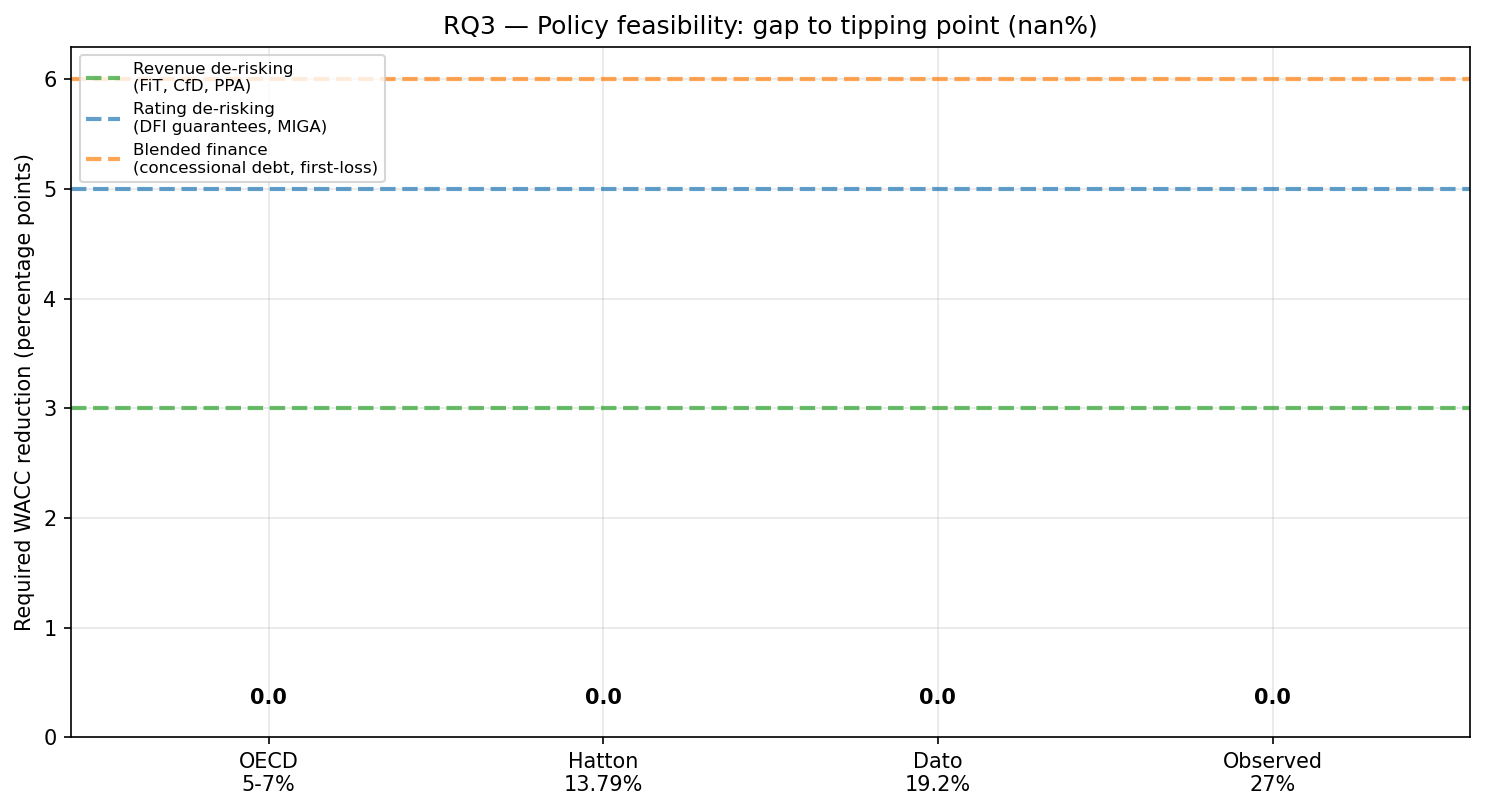

In [14]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Define instrument-class effectiveness (from literature)
instrument_classes = {
    "Revenue de-risking\n(FiT, CfD, PPA)": (3, "#2ca02c"),
    "Rating de-risking\n(DFI guarantees, MIGA)": (5, "#1f77b4"),
    "Blended finance\n(concessional debt, first-loss)": (6, "#ff7f0e"),
}

# Reference WACCs from the literature
references = {
    "OECD\n5-7%": 6,
    "Hatton\n13.79%": 13.79,
    "Dato\n19.2%": 19.2,
    "Observed\n27%": 27,
}

# Use the unconstrained inflection point
tipping = inflection.loc[inflection.constraint == "unconstrained", "solar > gas (GW)"].iloc[0]

x = np.arange(len(references))
gaps = [max(0, wacc - tipping) for wacc in references.values()]
colors = ["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728"]

bars = ax.bar(x, gaps, color=colors, alpha=0.75)

# Instrument ceilings
for i, (label, (effect, color)) in enumerate(instrument_classes.items()):
    ax.axhline(effect, color=color, linestyle="--", lw=2, alpha=0.7, label=label)

ax.set_xticks(x)
ax.set_xticklabels(list(references.keys()))
ax.set_ylabel("Required WACC reduction (percentage points)")
ax.set_title(f"RQ3 — Policy feasibility: gap to tipping point ({tipping:.1f}%)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3, axis="y")

for bar, gap in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, gap + 0.3, f"{gap:.1f}",
            ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(OUT / "fig_rq3_policy_feasibility.png", bbox_inches="tight")
plt.show()

In [ ]:
import pypsa
import pandas as pd
import numpy as np
from pathlib import Path

RESULTS = Path("/Users/fowfloi/Documents/pypsa-earth/results")

def load_net(name):
    d = RESULTS / name / "networks"
    files = list(d.glob("*.nc"))
    return pypsa.Network(files[0]) if files else None

def full_summary(n, label):
    """Dump everything relevant about one network."""
    # Connected buses only
    n.determine_network_topology()
    main = n.buses.sub_network.mode()[0]
    connected = n.buses.index[n.buses.sub_network == main]
    gens = n.generators[n.generators.bus.isin(connected)]
    sto = n.storage_units[n.storage_units.bus.isin(connected)]

    # Capacity by carrier
    cap = gens.groupby("carrier").p_nom_opt.sum() / 1e3
    sc = sto.groupby("carrier").p_nom_opt.sum() / 1e3

    # Generation by carrier (TWh) from generators
    gen_twh = {}
    for c in gens.carrier.unique():
        idx = gens[gens.carrier == c].index
        gen_twh[c] = n.generators_t.p[idx].sum().sum() / 1e6

    # Hydro generation from storage units
    hyd_idx = sto[sto.carrier == "hydro"].index
    hydro_twh = n.storage_units_t.p[hyd_idx].clip(lower=0).sum().sum() / 1e6 if len(hyd_idx) else 0.0

    # Load shedding (as generator)
    shed_idx = gens[gens.carrier == "load shedding"].index
    shed_twh = n.generators_t.p[shed_idx].sum().sum() / 1e6 if len(shed_idx) else 0.0

    # Demand
    load_cols = [c for c in n.loads_t.p_set.columns if c in connected]
    demand_twh = n.loads_t.p_set[load_cols].sum().sum() / 1e6

    # Gas split
    ccgt_cap = cap.get("CCGT", 0.0)
    ocgt_cap = cap.get("OCGT", 0.0)
    ccgt_gen = gen_twh.get("CCGT", 0.0)
    ocgt_gen = gen_twh.get("OCGT", 0.0)

    # CCGT and OCGT capacity factors (actual dispatch / theoretical max)
    ccgt_idx = gens[gens.carrier == "CCGT"].index
    ocgt_idx = gens[gens.carrier == "OCGT"].index
    ccgt_cf = (n.generators_t.p[ccgt_idx].sum().sum() / (gens.loc[ccgt_idx, "p_nom_opt"].sum() * 8784)) if len(ccgt_idx) and gens.loc[ccgt_idx, "p_nom_opt"].sum() > 0 else 0
    ocgt_cf = (n.generators_t.p[ocgt_idx].sum().sum() / (gens.loc[ocgt_idx, "p_nom_opt"].sum() * 8784)) if len(ocgt_idx) and gens.loc[ocgt_idx, "p_nom_opt"].sum() > 0 else 0

    # Fuel cost embedded in MC
    mc = gens[["carrier", "marginal_cost"]].drop_duplicates("carrier").set_index("carrier")["marginal_cost"].to_dict()

    # Emissions using network's own carrier CO2 intensity
    co2_map = n.carriers["co2_emissions"].reindex(gens.carrier.unique()).fillna(0.0)
    fuel_mwh = n.generators_t.p[gens.index].div(gens.efficiency.replace(0, np.nan), axis=1)
    emissions_t = fuel_mwh.mul(gens.carrier.map(co2_map), axis=1).sum().sum()

    # Transmission expansion
    new_lines_gwkm = ((n.lines.s_nom_opt - n.lines.s_nom).clip(lower=0) * n.lines.length).sum() / 1e3

    # Total cost
    total_cost_eur = n.objective
    EUR_TO_USD = 1 / 0.7532

    return {
        "label": label,
        "demand_TWh": round(demand_twh, 2),
        "shed_TWh": round(shed_twh, 3),
        "shed_pct": round(100 * shed_twh / demand_twh, 2) if demand_twh else 0,
        "solar_GW": round(cap.get("solar", 0), 2),
        "wind_GW": round(cap.get("onwind", 0), 2),
        "battery_GW": round(sc.get("battery", 0), 2),
        "hydro_GW": round(sc.get("hydro", 0), 2),
        "CCGT_GW": round(ccgt_cap, 2),
        "OCGT_GW": round(ocgt_cap, 2),
        "gas_GW_total": round(ccgt_cap + ocgt_cap, 2),
        "solar_TWh": round(gen_twh.get("solar", 0), 2),
        "wind_TWh": round(gen_twh.get("onwind", 0), 2),
        "hydro_TWh": round(hydro_twh, 2),
        "CCGT_TWh": round(ccgt_gen, 2),
        "OCGT_TWh": round(ocgt_gen, 2),
        "gas_TWh_total": round(ccgt_gen + ocgt_gen, 2),
        "CCGT_CF": round(ccgt_cf, 3),
        "OCGT_CF": round(ocgt_cf, 3),
        "MC_CCGT": round(mc.get("CCGT", 0), 2),
        "MC_OCGT": round(mc.get("OCGT", 0), 2),
        "emissions_Mt": round(emissions_t / 1e6, 2),
        "new_tx_GWkm": round(new_lines_gwkm, 1),
        "cost_BnUSD": round(total_cost_eur * EUR_TO_USD / 1e9, 3),
    }

# Build the comparison table
runs = [
    # Baselines
    ("cap_exp_2030_uniform_WACC",                  "B1 uniform 10% uncon"),
    ("cap_exp_2030_uniform_WACC_NDC",              "B2 uniform 10% NDC"),
    ("cap_exp_2030_split_wacc",                    "B3 Hatton uncon"),
    ("cap_exp_2030_split_wacc_NDC",                "B4 Hatton NDC"),
    # Primary sweep — unconstrained
    ("nigeria_2030_wacc_0700",                     "sweep 7% uncon"),
    ("nigeria_2030_wacc_1100",                     "sweep 11% uncon"),
    ("nigeria_2030_wacc_1379",                     "sweep 13.79% uncon"),
    ("nigeria_2030_wacc_2700",                     "sweep 27% uncon"),
    # Primary sweep — NDC
    ("nigeria_2030_wacc_0700_ndc",                 "sweep 7% NDC"),
    ("nigeria_2030_wacc_1100_ndc",                 "sweep 11% NDC"),
    ("nigeria_2030_wacc_1379_ndc",                 "sweep 13.79% NDC"),
    ("nigeria_2030_wacc_2700_ndc",                 "sweep 27% NDC"),
    # Battery sensitivity
    ("nigeria_2030_wacc_0900_battery_hatton",      "battery 14.68% @ solar 9%"),
    ("nigeria_2030_wacc_1100_battery_hatton",      "battery 14.68% @ solar 11%"),
    # Gas price sensitivity
    ("nigeria_2030_wacc_1379_gas_218",             "gas $2.18 @ renew 13.79%"),
    ("nigeria_2030_wacc_1379_gas_400",             "gas $4.00 @ renew 13.79%"),
    ("nigeria_2030_wacc_1379_gas_600",             "gas $6.00 @ renew 13.79%"),
    # Combined
    ("nigeria_2030_wacc_0700_gas_450_ndc",         "combined: renew 7% + gas $4.50"),
]

rows = []
for name, label in runs:
    n = load_net(name)
    if n is None:
        print(f"MISSING: {name}")
        continue
    rows.append(full_summary(n, label))

df = pd.DataFrame(rows)
df.to_csv("analysis/diagnostic_full.csv", index=False)

# Print column-wise so you can read it
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
print(df.to_string(index=False))